In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\KIIT0001\Desktop\resume_matcher\data\cleaned_resume.csv")

In [5]:
df.head()

,ID,Resume_str,Resume_html,Category,cleaned_resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administratormarketing associate hr adminis...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...


In [6]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'cleaned_resume'], dtype='object')


In [7]:
print(df['cleaned_resume'].iloc[0])

hr administratormarketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customerfocused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction team management marketing savvy conflict resolution techniques training development skilled multitasker client relations specialist accomplishments missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality systems hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses seminars customer service sales strategies inventory control loss prevention safety time management leadership performance assessment experience hr administratormarketing associate hr administrator dec current company name － city state helps develop 

In [8]:
resume = df['cleaned_resume'].iloc[0]
print(resume)

hr administratormarketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customerfocused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfaction team management marketing savvy conflict resolution techniques training development skilled multitasker client relations specialist accomplishments missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality systems hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses seminars customer service sales strategies inventory control loss prevention safety time management leadership performance assessment experience hr administratormarketing associate hr administrator dec current company name － city state helps develop 

In [9]:
job_desc = """
Looking for HR Administrator with experience in human resources,
employee relations, payroll, recruitment, communication skills,
and data management. Candidate should have knowledge of benefits,
training, and performance management.
"""

In [11]:
len(resume.split())

503

In [12]:
from collections import Counter

words = resume.split()
print(Counter(words).most_common(15))

[('customer', 12), ('marketing', 11), ('company', 10), ('service', 9), ('－', 9), ('city', 9), ('state', 9), ('relations', 8), ('name', 7), ('medical', 7), ('management', 6), ('employee', 6), ('dec', 5), ('billing', 5), ('hr', 4)]


In [13]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_job_desc = clean_text(job_desc)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Step 1: Fix all NaN issues
df['cleaned_resume'] = df['cleaned_resume'].replace([np.nan, None], '').astype(str)

# Step 2: Remove empty strings
df = df[df['cleaned_resume'].str.strip() != '']

# Step 3: Verify no NaN
print(df['cleaned_resume'].isna().sum())  # should print 0

# Step 4: Build vectorizer WITHOUT stop_words first to test
all_texts = list(df['cleaned_resume']) + [cleaned_job_desc]

vectorizer = TfidfVectorizer(stop_words=None, max_features=5000)
tfidf_matrix = vectorizer.fit_transform(all_texts)

print("Success! Shape:", tfidf_matrix.shape)

0
Success! Shape: (2484, 5000)


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

job_vector = tfidf_matrix[-1]        # last entry is job description
resume_vectors = tfidf_matrix[:-1]   # all resumes

scores = cosine_similarity(job_vector, resume_vectors)[0]
print("Scores calculated:", len(scores))

Scores calculated: 2483


In [17]:
df['match_score'] = scores
df['match_score_pct'] = (df['match_score'] * 100).round(2)

In [18]:
top_matches = df.sort_values('match_score', ascending=False).head(10)
print(top_matches[['ID', 'Category', 'match_score_pct']])

            ID Category  match_score_pct
55    30862904       HR            41.96
2330  16244633     ARTS            40.31
72    26289308       HR            39.77
27    29297973       HR            38.32
31    18316239       HR            38.12
52    72231872       HR            38.12
18    73077810       HR            37.96
9     32896934       HR            37.82
68    15041689       HR            37.74
4     17812897       HR            36.83


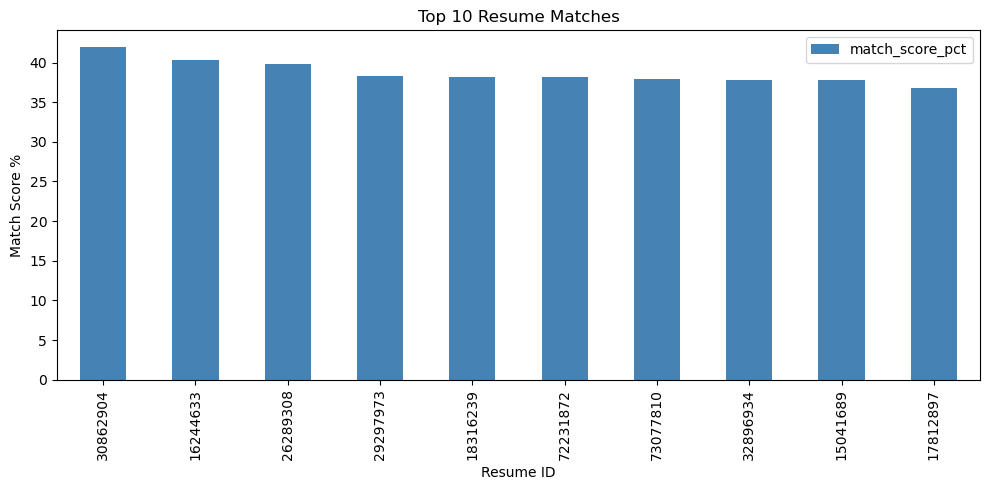

In [19]:
import matplotlib.pyplot as plt

top_matches.plot(kind='bar', x='ID', y='match_score_pct', 
                 color='steelblue', figsize=(10,5))
plt.title('Top 10 Resume Matches')
plt.ylabel('Match Score %')
plt.xlabel('Resume ID')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

job_vector = tfidf_matrix[-1]
resume_vectors = tfidf_matrix[:-1]
scores = cosine_similarity(job_vector, resume_vectors)[0]
print("Done! Total scores:", len(scores))

Done! Total scores: 2483


In [21]:
df['match_score'] = scores
df['match_score_pct'] = (df['match_score'] * 100).round(2)
print(df[['ID', 'Category', 'match_score_pct']].head())

         ID Category  match_score_pct
0  16852973       HR            26.76
1  22323967       HR            13.79
2  33176873       HR            28.91
3  27018550       HR             9.46
4  17812897       HR            36.83


In [22]:
top_matches = df.sort_values('match_score', ascending=False).head(10)
print(top_matches[['ID', 'Category', 'match_score_pct']].to_string())

            ID Category  match_score_pct
55    30862904       HR            41.96
2330  16244633     ARTS            40.31
72    26289308       HR            39.77
27    29297973       HR            38.32
31    18316239       HR            38.12
52    72231872       HR            38.12
18    73077810       HR            37.96
9     32896934       HR            37.82
68    15041689       HR            37.74
4     17812897       HR            36.83


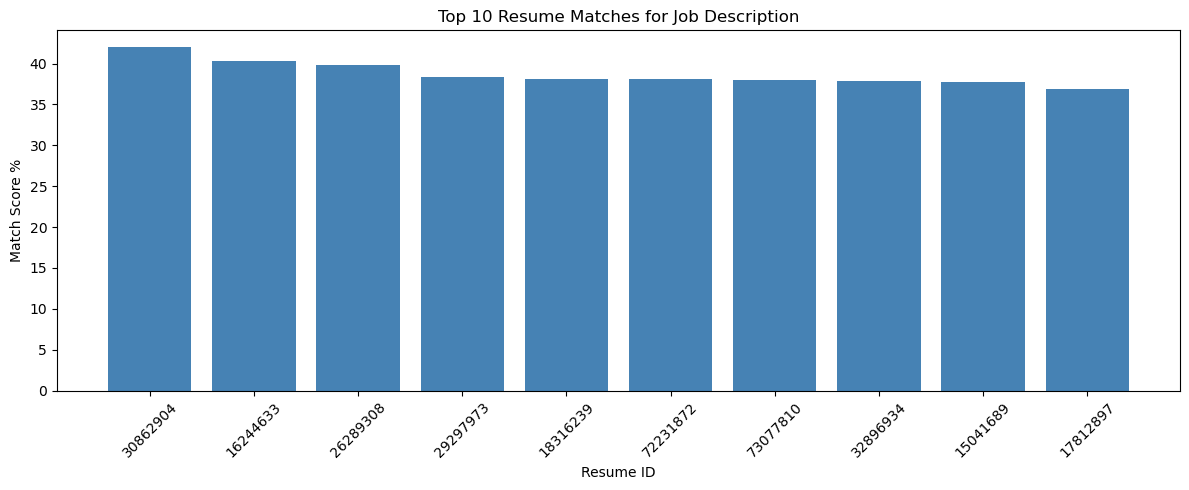

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(range(len(top_matches)), top_matches['match_score_pct'], color='steelblue')
plt.xticks(range(len(top_matches)), top_matches['ID'], rotation=45)
plt.title('Top 10 Resume Matches for Job Description')
plt.ylabel('Match Score %')
plt.xlabel('Resume ID')
plt.tight_layout()
plt.show()